In [1]:
# 3rd party imports
import torch
from torch import nn as NN
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

# local imports
from neural_network import StockModel
from settings import project_settings
from dataset_handler import DataManager

In [2]:
# --------------------------------------------------
# GLOBAL SPEED SETTINGS
# --------------------------------------------------
DEVICE = project_settings.DEVICE

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True

In [3]:
# --------------------------------------------------
# HYPER PARAMETERS
# --------------------------------------------------
INPUT_SIZE = 5
LSTM_HIDDEN_SIZE = 256
LSTM_NUM_LAYERS = 2
LSTM_DROPOUT = 0.2
FC1_OUT_FEATURES = 128
FC_DROPOUT = 0.2
OUTPUT_SIZE = 5

EPOCHS = 172
BATCH_SIZE = 146
DIRECTION_LOSS_WEIGHT = 3
MAX_LOSS_WEIGHT = 1
MIN_LOSS_WEIGHT = 1
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
FLUCTUATION_LOSS_WEIGHT = 1

CROSS_ENTROPY_LOSS_WEIGHTS = torch.tensor([1, 3, 3], dtype=torch.float, device=DEVICE)

In [4]:
# load the data
csv_file_name = "XRP_USDT.csv"
dataframe_manager = DataManager(
    csv_file=csv_file_name,
    device=DEVICE,
)

# the columns to use
feature_cols = ["open", "EMA_0_diff", "EMA_1_diff", "ADX_2", "RSI_3"]
target_col = ["future_max", "future_min", "label"]

# get training and testing tensors
trainX, trainY = dataframe_manager.get_train_tensors(
    feature_col=feature_cols, target_col=target_col
)
testX, testY = dataframe_manager.get_test_tensors(
    feature_col=feature_cols, target_col=target_col
)

# setup training dataset
train_dataset = TensorDataset(trainX, trainY)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

In [ ]:
# --------------------------------------------------
# TRAIN
# --------------------------------------------------

# create the model
model = StockModel(
    INPUT_SIZE,
    LSTM_HIDDEN_SIZE,
    LSTM_NUM_LAYERS,
    LSTM_DROPOUT,
    FC1_OUT_FEATURES,
    FC_DROPOUT,
    OUTPUT_SIZE,
    device=DEVICE,
)

# create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# create loss functions for regression (max/min) and classification (direction)
regression_criterion = NN.MSELoss()
classification_criterion = NN.CrossEntropyLoss(weight=CROSS_ENTROPY_LOSS_WEIGHTS)

# get number of samples and batches
num_samples = len(trainX)
num_batches = max(1, num_samples // BATCH_SIZE)

# create a scaler
scaler = torch.amp.GradScaler(enabled=(DEVICE == "cuda"))

# train loop
for epoch in range(EPOCHS):

    # switch model to training
    model.train()
    total_loss = 0.0

    # get bacthes
    for x_batch, y_batch in train_loader:

        # reset the gradient
        optimizer.zero_grad(set_to_none=True)

        # use float16 or float32 based on the device
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE == "cuda")):

            # make prediction
            raw_max_pred, raw_min_pred, raw_direction_pred = model(x_batch)

            # extract the final predictions
            max_pred = raw_max_pred[:, -1]
            min_pred = raw_min_pred[:, -1]
            direction_pred = raw_direction_pred[:, -1]

            # calculate losses
            max_loss = regression_criterion(max_pred.squeeze(), y_batch[:, 0, 0])
            min_loss = regression_criterion(min_pred.squeeze(), y_batch[:, 1, 0])
            direction_loss = classification_criterion(direction_pred, y_batch[:, 2, 0].long())

            # calculate the fluctuation between each prediction to make it smoother
            max_diff = raw_max_pred[:, 1:] - raw_max_pred[:, :-1]
            min_diff = raw_min_pred[:, 1:] - raw_min_pred[:, :-1]

            fluctuation_loss = FLUCTUATION_LOSS_WEIGHT * (
                regression_criterion(max_diff, torch.zeros_like(max_diff)) +
                regression_criterion(min_diff, torch.zeros_like(min_diff))
            )

            # combine based on weights
            loss = (
                direction_loss * DIRECTION_LOSS_WEIGHT
                + max_loss * MAX_LOSS_WEIGHT
                + min_loss * MIN_LOSS_WEIGHT
                + fluctuation_loss
            )

        # backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # add loss
        total_loss += loss.item()

    # log
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{EPOCHS}] Loss: {avg_loss:.6f}")

Epoch [1/172] Loss: 3.092451
Epoch [2/172] Loss: 3.034052
Epoch [3/172] Loss: 3.023870
Epoch [4/172] Loss: 3.016132
Epoch [5/172] Loss: 3.007472
Epoch [6/172] Loss: 3.002517
Epoch [7/172] Loss: 2.998679
Epoch [8/172] Loss: 2.994979
Epoch [9/172] Loss: 2.992175
Epoch [10/172] Loss: 2.992069
Epoch [11/172] Loss: 2.987577
Epoch [12/172] Loss: 2.983662
Epoch [13/172] Loss: 2.980559
Epoch [14/172] Loss: 2.976284
Epoch [15/172] Loss: 2.971579
Epoch [16/172] Loss: 2.966436
Epoch [17/172] Loss: 2.962130
Epoch [18/172] Loss: 2.954429
Epoch [19/172] Loss: 2.943591
Epoch [20/172] Loss: 2.931156
Epoch [21/172] Loss: 2.965915
Epoch [22/172] Loss: 2.953535
Epoch [23/172] Loss: 2.936365
Epoch [24/172] Loss: 2.923933
Epoch [25/172] Loss: 2.908253
Epoch [26/172] Loss: 2.879772
Epoch [27/172] Loss: 2.852621
Epoch [28/172] Loss: 2.830263
Epoch [29/172] Loss: 2.780613
Epoch [30/172] Loss: 2.733585
Epoch [31/172] Loss: 2.678552
Epoch [32/172] Loss: 2.631691
Epoch [33/172] Loss: 2.575595
Epoch [34/172] Loss

In [ ]:
# --------------------------------------------------
# TEST (BATCHED)
# --------------------------------------------------

# switch model for inference
model.eval()

# hold predicted values
max_preds, min_preds, direction_preds = [], [], []

# with no gradient
with torch.no_grad():

    # iterate
    for i in range(0, len(testX), BATCH_SIZE):

        # get current batch
        x_batch = testX[i : i + BATCH_SIZE]

        # predict
        max_pred, min_pred, direction_pred = model(x_batch)

        # we want the last timestep prediction for each sequence in the batch
        # max_pred shape: (batch_size, sequence_length)
        # we take the last timestep: max_pred[:, -1]
        # this gives us (batch_size,) for max and min predictions
        max_pred_last = max_pred[:, -1].cpu()
        min_pred_last = min_pred[:, -1].cpu()
        direction_pred_last = direction_pred[:, -1].cpu()

        # append
        max_preds.extend(max_pred_last.tolist())
        min_preds.extend(min_pred_last.tolist())
        direction_preds.extend(direction_pred_last.argmax(dim=1).tolist())


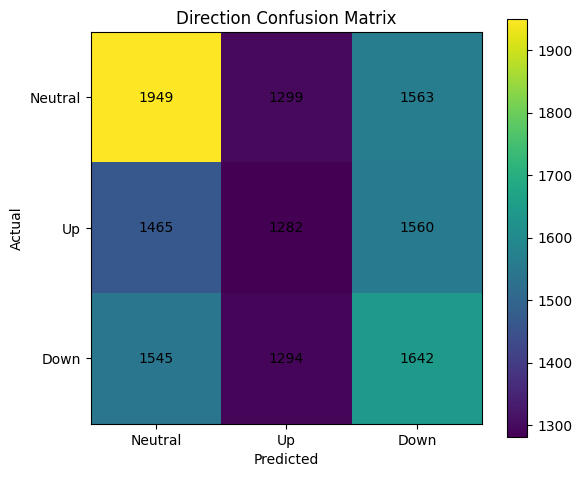

In [ ]:
# --------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------

# calculate the matrix
cm = confusion_matrix(testY[:, 2, :].squeeze(1).cpu().numpy(), direction_preds)
class_names = ["Neutral", "Up", "Down"]

# create figure
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

# add lables
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)

# add info
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Direction Confusion Matrix")

# write numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# show
plt.tight_layout()
plt.show()

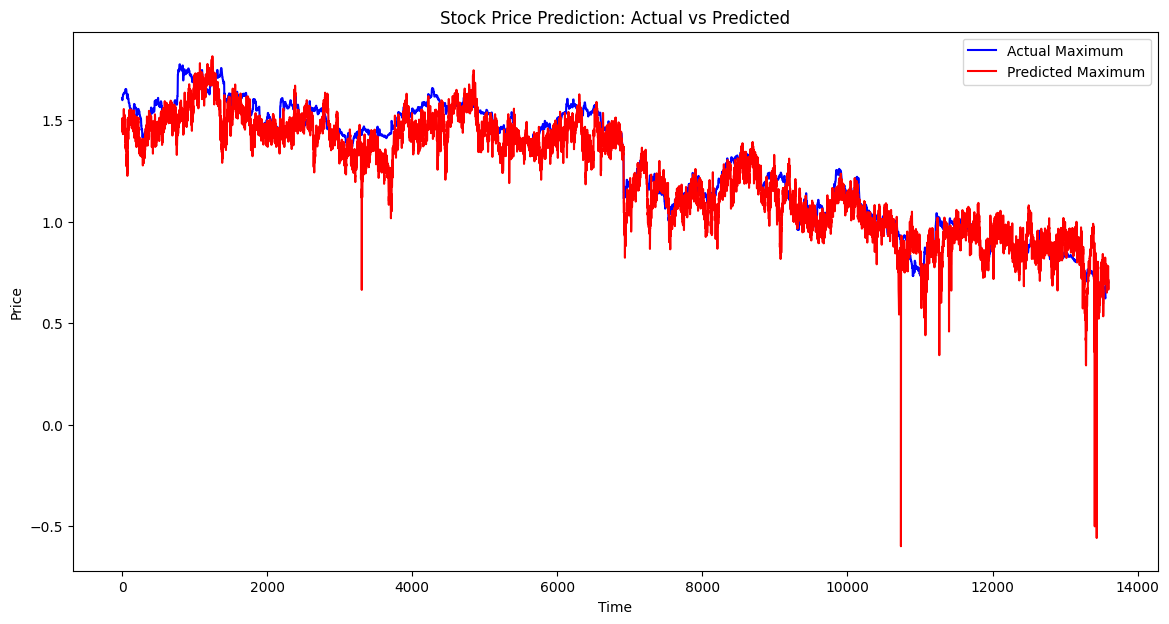

In [ ]:
# --------------------------------------------------
# PLOT ACTUAL VS PREDICTED MAX
# --------------------------------------------------

# create figure
plt.figure(figsize=(14, 7))

# add vals
plt.plot(testY[:, 0].cpu(), color="blue", label="Actual Maximum")
plt.plot(max_preds, color="red", label="Predicted Maximum")

# add labels
plt.title("Stock Price Prediction: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Price")

# show
plt.legend()
plt.show()


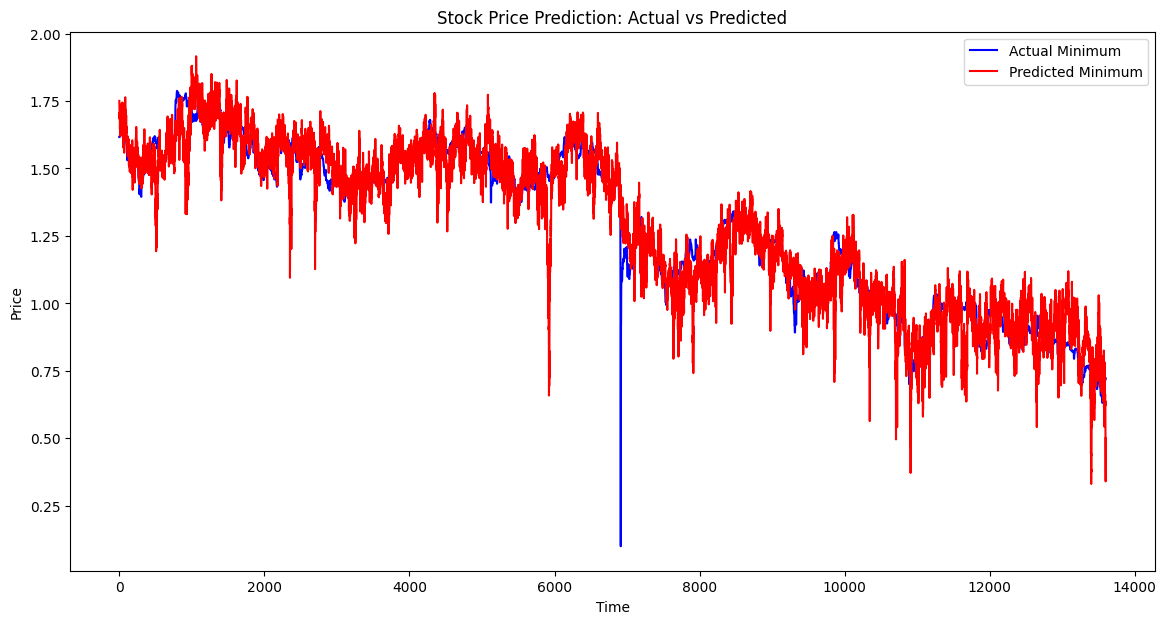

In [ ]:
# --------------------------------------------------
# PLOT ACTUAL VS PREDICTED MIN
# --------------------------------------------------

# create figure
plt.figure(figsize=(14, 7))

# add vals
plt.plot(testY[:, 1].cpu(), color="blue", label="Actual Minimum")
plt.plot(min_preds, color="red", label="Predicted Minimum")

# add labels
plt.title("Stock Price Prediction: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Price")

# show
plt.legend()
plt.show()
